# 1.0 Apuntes Spark: Introduccion, conceptos basicos y preparacion del entorno

Al fin tras haber revisado y aprendido distintas herramientas de Big Data y procesamiento de datos, llegamos a Spark.

Apache Spark se ha convertido en una herramienta basica que da soporte a multiples aplicaciones de procesamiento de Big Data, destacandose como **el motor principal de computacion para IA's de *machine learning***

> Esto es asi ya que los modelos de *machine learning* necesitan acceso a cientos de millones de datos para poder aprender de forma initerrumpida.

Podemos definirla como: **una plataforma de computacion distribuida para desarrollar, probar y llevar a produccion algoritmos a escala big data de forma sencilla y eficiente**

#### 1.1 Anteriormente.... Hadoop: HDFS y MapReduce

Lo aprendido en la unidad anterior con Hadoop, nos explicaba que el sistema de procesamiento de datos estaba orientado a hacerlo por lotes, **diviendo el trabajo en 2 subtareas (Map y Reduce). *map* aplica operaciones sobr euna porcion de los datos originales y *reduce* recolecta los resultados parciales para obtener resultados de agregados finales.

**Sin embargo es un sistema ineficiente para algoritmos que requieran una iteracion, como el analisis estadistico o el machine learning**

> Estos algoritmos evaluan de forma repetitiva funciones y parametros sobre subconjuntos de los mismos datos.
>

Ademas Hadoop requiere leer otra vez cada fichero del HDFS para iterarlo y su motor no ofrece una implementacion directa del proceso de iterar, sino unicamente podemos lanzar explicitamente secuencias de replica.

Otro aspecto dilapidaria para Hadoop, **es que no permite explorar los datos de forma interactiva** siendo esencial en algun campo de analitica. 

> Todas las operaciones de filtrado o transformacion requieren lanzar una nueva tarea que lea el disco y devbuelva los resultados al disco, hacieno que el proceso sea ineficaz para una fase exploratoria.

En definitiva: ***Hadoop* es una plataforma que se utiliza unicamente para lo que fue diseñada, pero para nuevas necesidades de computacion Spark y otras herramientas son el estandar desde el que empezar**

# 2.0 ¿Que es Apache Spark?

**Es una plataforma de computacion distribuida flexible**, sus principales caracteristicas son:

- **Hace un uso masivo de la memoria RAM** para acelerar las tareas de procesamiento y calculo con grandes cantidades de datos
- **Permite definir de manera sencilla procesos de calculos complejos**, enlaznado etapas o pasos de calculo.

> Esto permite en definitiva **ejecutar aplicaciones hasta 100 veces mas rapido que en Hadoop**

Debido a esta concepcion, Spark permite desarollar algoritmos muy eficientes para tareas avanzadas que neecsitan operar sobre los mismos datos de forma recurrente (como es en el *machine learning*)

Algunas caracteristicas adicionales son:

- 1º **Spark esta basado en el lenguaje *scala***

> Basado en lenguajes de maquinas virtuales de Java, pero con posibilidad de usar programas para usar Java, Python o R

- 2º **Las librerias incluidas de Spark a alto nivel** para trabajar con BBDD, librerias de *machine learning*, analisis de graficos o procesamiento en streaming de datos.

### 2.1 Un poco de Historia.....

Spark nace en 2010 a raiz de una investigacion algoritmica en Berkley, para resolver problemas de computacion de big data en trabajos que requieran exploracion de datos y/o iteracion repetida de datos.

> Hasta ese momento, Hadoop era la plataforma mas extendida en procesamiento distribuido en paralelo en clusters de big data.
>
> Tras utilizarse mucho, descubrieron sus fallas y sus beneficios, para poder desarrollar **otra plataforma mas generalista que superara las limitaciones**

El motor *MapReduce* resultaba util para procesos de calculo *aciclicos*, es decir, compuestos por una sencuencai de pasos, lineal, sin iteraciones. **Pero para todos los otros tipos de procesamientos de algoritmos no valia**

> Generalmente los procesos de datos tienen **flujos iterativos**, dan pasadas sobre lsod atos de entrada para aprender y mejorar el algoritmo.
>
> En MapReduce, supondria que cada iteracion, fuera un trabajo distinto, lanzando la plataforma de manera separada y volviendo a cargar los datos independientemente del resto calculado. Ademas en cada iteracion los datos se deben guardar en disco, haciendo que sea muy infeciente en procesos asi.

##### 2.2 ¿Como solucionaron estas limitaciones entonces?

Spark se concivio con ciertas herramientas o caracteristicas:

- 1º Se creo**una API que permitiera escribir aplicaciones con multiples pasos de calculo y flujos complejos de forma sencilla**
- 2º Se desarrollo un motor de calculo distribuido que podia ejecutar estos procesos de manera muy eficiente, **manejando y compartiendo datos en memoria entre los pasos**
- 3º Se implemento **un interprete interactivo con u motor propio para ejecutar consultas**
  
> Parecido a SQL, asi era mas facil realizar analisis de datos

- 4º Se incluyeron librerias para el procesamiento de datos mas necesarios, siendo las mas relevantes las siguiente:

>> ***MLlib***: Libreria de machine learning de Spark
>>
>> ***Spark Streaming***: Libreria para procesar datos en tiempo real
>>
>> ***GraphX***: Libreria para procesar graficos de manera eficiente

Ademas, el equipo original de Spark, cedio la aplicacion a Apache (los creadores de Hadoop) y decidieron seguir trabajando en otra aplicacion anexa que potenciara la herramienta: ***Databricks***

## 3.0 El funcionamiento de Spark: *los Clusters de Spark*

Antes de seguir con las herramientas de Spark, vamos a entender que son **los clusters de Sparks** a los que nos hemos conectado a traves de Hadoop.

Hemos visto que la concepcion de Spark dio como primer paso **la creacion de API's para la generacion de flujosd e trabajo sencillos**, a traves de este principio, **Spark se configura como un conjunto de procesos independientes, que son coordinados por una aplicacion**

> Esta aplicacion funciona como *driver* entre las aplicaciones, el cluster manager y **los nodos esclavo**


##### 3.1 SparkSession: El controlador de SparkContext

Desde la actualizacion de Spark, **para hacerlo aun a mas alto nivel**, la aplicacion a la que se conecta el usuario y con la que interactua con toda la estructura de Spark, es el denominado ***SparkSession***

**Es el punto de acceso de nuestra aplicacion a todas las funcionalidades de la plataforma**

> Al trabajar con pyspark, se generara automaticamente una sesion.


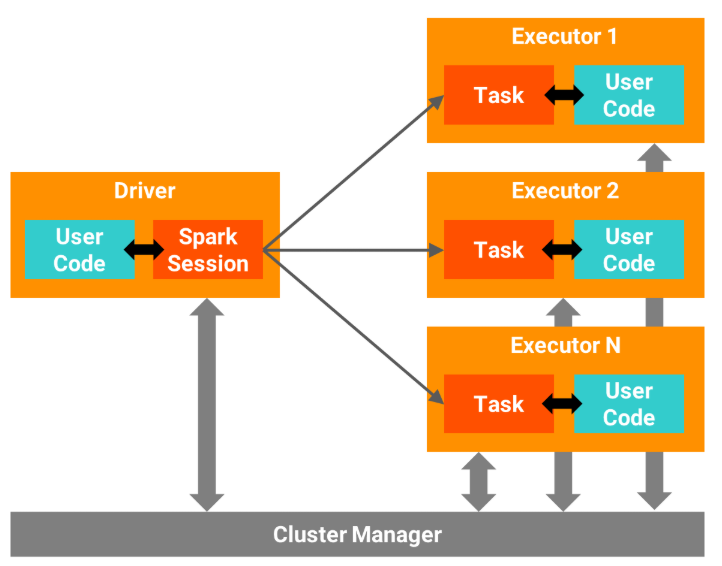


## 4.0 SparkContext: La arquitectura interna de Spark

> Como indicaba en la anterior seccion, SparkSession es la que conecta directamente al usuario con el resto de la arquitectura, **dejando a *Sparkcontext* unicamente como gestor interno de los RDDs y tareas solicitados**

***SparkContext*** coordina los procesos con el cluster manager, **quien se encarga de gestionar los recursos de la aplicacion**, diviendo los recursos de los nodos segun las tareas, en concreto, **sus capacidades de RAM y CPU**

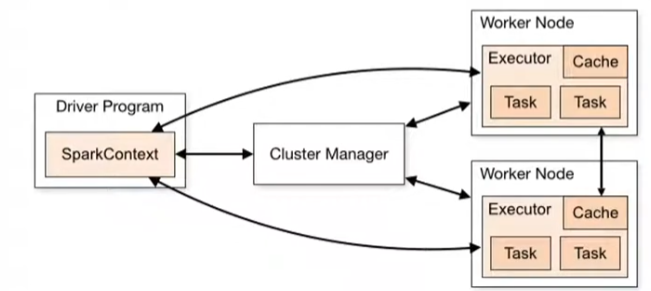

##### 4.1 Proceso por pasos del funcionamiento de Spark

Si se explica por pasos, Spark ejecuta el siguiente orden con el sistema de elementos explicado:

- 1º Al generarse una tarea a realizar, *SparkContext* se conecta al *Cluster Manager*
- 2º Tras establecer la conexion, Spark "concreta la cantidad y prepara los nodos esclavo" ya sea para ejecutar como almacenar datos
- 3º El *SparkContext* envia el codigo de la aplicacion a los nodos esclavo directamente.
- 4º Por ultimo envia las subtareas necesarias a estos nodos, siendo las subtareas unidades de trabajo para ejecutar con los recursos de los nodos.

##### 4.2: 3 tipos de configuracion del cluster

Este conjunto de elementos de Spark se puede configurar de 3 modos:

- ***Standalone***: es el cluster mas sencillo y facil de configurar
  > Ejemplo: Un conjunto de 6 nodos, 5 esclavos y 1 de *cluster manager*, conectamos el *driver* para conectarse y coordinarse entre ellos y listo
- ***Hadoop YARN***: Utilizar HDFS Hadoop como base
  > Ejemplo: **Construir la misma arquitectura pero sobre un cluster de Hadoop**
- ***Kubernetes***: Es una plataforma de contenedores distribuida.
  > Ejemplo: Dispone de nodos "maestro" que hacen de cluster manager y otros que son los esclavo. Podemos reutilizar esta arquitectura predefinida para especificar nuestro cluster Spark

## 5.0 Elementos de Spark: Apache Spark Core y sus componentes

**Es el motor principal de ejecucion de la plataforma**, y tiene 2 caracteristicas principales:

- 1º Todas las funcionalidad se construyen sobre esta, por lo que **el motor tiene la logica ycodigo de la ejecucion de los programas**
- 2º Proporciona calculos en memoria referenciando *datasets* en almacenamiento externo.

Esta compuesto por los elementos y librerias basicas para el funcionamiento de la plataforma, estos son:

- Una implementacion de procesos (planificador, distribuidor de tareas, reponsables de programar y coordinar) con el gestor cluster
- Una abstraccion para manejar datos en memoria distribuida (los RDDs)
- Un modelo de calculo para ejecutar flujos de procesos sobre los datos de manera flexible y eficiente: los DAGs

### 5.1 Componentes de Spark (De Apache Spark Core): *los RDDs*

Los *Resilient Distributed Datasets* (***RDDs***) **son estructuras de datos propias de Spark sobre las que se basa la arquitectura de la aplicacion**.

Se les podria definir como una abstraccion que representa una coleccion de datos particionados y repartidos por multiples nodos de un cluster, **como los HDFS, pero con la diferencia en la capacidad de recuperacion frente a fallos gracias la recuperacion de informacion de otros nodos o de recalcular datos perdidos**

Estos RDDs nacieron para suplir 2 limitaciones de los HDFS de Hadoop:

- Aumentar la velocidad de procesamiento al ejecutarse en la memoria RAM
- Permitir la iteracion de los flujos de datos para realizar nuevos calculos de manera sencilla

> Ademas los RDDs facilitan el trabajo al usuario a traves de otras abstracciones de mas alto nivel, para poder trabajar con datasets, dataframes y tablas tipo SQL

Los RDDs tienen una serie de atributos, **siendo el comun a todos, *la transparencia* para el usuario (el usuario no realiza ninguna configuracion)**:

- 1º *Particionamiento*: la coleccion de datos (valores simples, secuencias...) se divide en varias partes o bloques.
- 2º *Distribuido*: las particiones son repartidas por el cluster.
- 3º *Robustez*: puede regenerar datos perdidos o corrompidos, recalculando los pasos necesarios a partir de los datos previos.
- 4º *Datos en memoria*: Mantiene la mayor cantidad posible de datos en memoria durante el mayor tiempo posible. Se encarga de transferir datos entre memorias y discos automaticamente cuando sea necesario, optimizando la utilizacion de los recursos.
- 5º *Inmutabilidad*: No puede modificarse el contenido una vez creado. Cada vez que se genera una operacion, se genera un RDD nuevo.
- 6º *Lazy Operation*: Es una funcionalidad que gestiona y ordena la operacion requerida, y la ejecuta solo cuando se solicita el acceso al resultado. Sino se solicita, solo se quedan las ordenes fijadas y referenciadas para saber como se ejecutara.
- 7º *Datos en Cache*: Puedes hacer que todos los datos se mantenga en memoria.
  > Esta ultima opcion, si que da posibilidad de configuracion por parte del usuario.

### 5.2 Componentes de Spark (De Apache Spark Core): *los DAGs*

Los *directed acyclic graph* (***DAGS***) **son la representacion de los pasos dados para obtener el resultado por los RDDs desde los original (*RDDs Padres*) hasta los RDDs finales (*RDDs Hijos*)**

> Los grafos dirigidos *(directed graph)* solo pueden ir de un nodo a otro en una direccion
>
> Un grafo acilico *(acyclic graph)* es aquel partiendo de un nodo, no puede volver al mismo nodo, empieza y termina en distintos nodos.

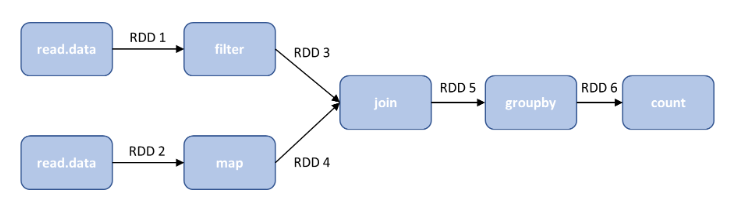

Convertir el proceso en un grafico proporciona una serie de ventajas, frente al HDFS:

- 1º Hace que sea **mas sencillo crear flujos o secuencias complejas**
- 2º Si se produce un error **puede reconstruir los RDDs a artir de los previos, repitiendo los pasos necesarios** (tolerancia a fallos)
- 3º **No hace falta que se jecute una vez se crea**, unicamente cuando se solicite los resultados
  > la llamada *Lazy Operation*
- 4º Es optimizable en **la forma de repartir y ejecutar calculos en el cluster**
> Ya que en todo momento conoce los pasos necesaros y esta constantemente buscando la mejor manera de hacerlo en memoria, por lo que ajusta la cantidad de datos para minimizar el intercambio de datos entre nodos para cada paso.

Los *DAGs* siguiendo estos principios, aplican **2 metodologias de transformacion distintas segun interese**:

- **Tranformacion Estrecha**
- **Transformacion Amplia**

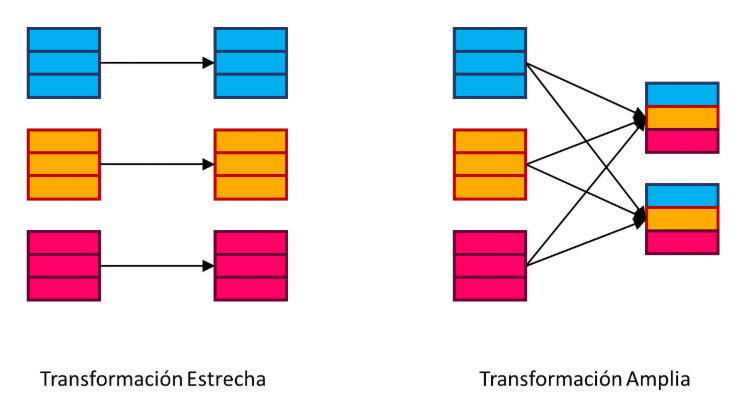

###### 4.2.1 Tranformacion Estrecha (*lazy operations*)

Es un modo de operar que se caracteriza por **calcular la porcion del resultado en cada nodo**, conociendo unicamente la porcion de datos de entrada de ese nodo

> Transformaciones tipo serian: las *map*, filtrados y muestreo.
>
> Es un proceso que **siempre devuelve un RDD nuevo, incluso si es para actualizarlos**

Estas operaciones **pueden realizarse en memoria de cada nodo**

###### 4.2.2 Tranformacion Amplia (*acciones*)

Es un modo de operar que se caracteriza porque **los datos de entrada para realizar el calculo de la porcion del resultado, puede venir de cualquier nodo**

> Transformaciones tipo serian: las agregaciones por una clave, los *join* y la interseccion.
>
> Es un proceso **RDD que no es una transformacion**

Estas operaciones **necesitas intercambiar datos por red o salvarlos en disco para completar calculos**

###### 4.2.3 Los DAGs en Spark

Spark hace uso de estos 2 modos de calculo junto a las estructruras RDDs para realizar los procesos optimizados que:

- **Siempre intentan que la mayoria de calculos se realizacen como operaciones *estrechas*** (ya que se realizan en memoria)
- **Los limites entre etapas parabelizables** ( es decir, procesos que son necesarios realizar en conjunto en nodos) **son marcados por *operaciones amplias***

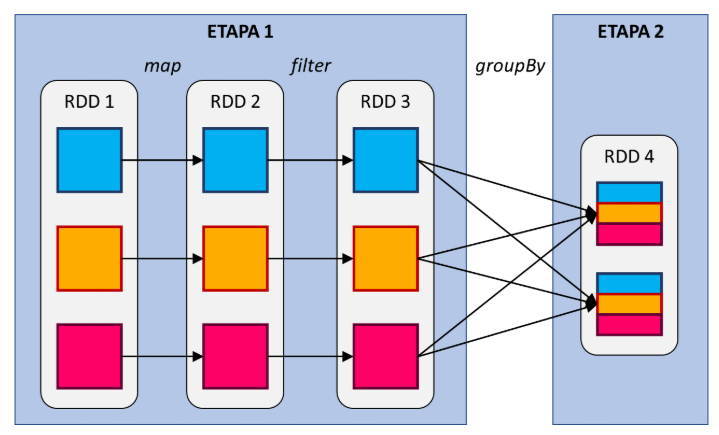

Este proceso termina hacer pasos **cuando llega a un RDD final que no genera otro RDD resultado**, o lo que es llamado como ***acciones***

> Ejemplos: grabar resultados finales en un disco, contar el nº de elementos del resultado o mostrar las N primeros resultados.

Las acciones se ejecutan con **los resultados finales calculados y disponibles**

### 6.0 Gestor de plataforma de ejecucion: *Standalone Scheduler*

Al igual que en Hadoop, Spark requiere del uso de un gestor de clusters (como YARN o Apache Mesos) **que le permite escalar el trabajo de 1 a las maquinas necesarias para llevarlo a cabo**

En este caso Spark Incluye ***Standalone Scheduler*** que esta pensado para **ejecutar Spark en una sola maquina de forma directa, sin las complicaciones de tener que configurar un gestor adicional**